# 순환 신경망 기반 감성 분석 (네이버 영화 리뷰)
1. 데이터 준비
2. 모델 구축 및 컴파일
3. 모델 학습
4. 모델 평가
5. 예측
6. 배포 (저장, 재사용)

## 1. 데이터 준비
    1-1. 데이터 로딩
    1-2. 데이터 전처리
    1-3. 데이터 분리 
    1-4. 학습용 데이터 준비
    1-5. 테스트용 데이터준비 

### 1-1. 데이터 로딩

In [1]:
# naver_movie_review.csv
import pandas as pd
datafile = './data/naver_movie_review.csv'

review_df = pd.read_csv(datafile)
review_df.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 1-2. 데이터 전처리
- 결측치 제거
- 정제 (한글만 남기고 모두 삭제)
- 중복치 제거
- 형태소 분석기로 토큰화

#### 1-2-1. 결측치 제거

In [2]:
# 결측치 확인 (결측치 개수 확인)
# review_df.info()
review_df.isnull().sum()

id          0
document    8
label       0
dtype: int64

In [155]:
# 결측치가 있는 레코드(행) 확인
review_df[review_df.document.isnull()]

,id,document,label
25857,2172111,NaN,1
55737,6369843,NaN,1
110014,1034280,NaN,0
126782,5942978,NaN,0
140721,1034283,NaN,0
155746,402110,NaN,1
157899,5026896,NaN,0
177097,511097,NaN,1


In [3]:
# 결측치 제거
review_df.dropna(inplace=True)

In [5]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        199992 non-null  int64 
 1   document  199992 non-null  object
 2   label     199992 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.1+ MB


#### 1-2-2. 정제
* 한글과 공백을 제외한 문자는 공백으로 치환하여 제거
* 한글이 없었던 문장은 공백만 남아있게 되므로, 결측치 삭제 처리 진행 필요

In [4]:
import re
# 한글과 공백 제외하고 모두 공백으로 치환
review_df['clean_doc'] = review_df.document.apply(lambda x: re.sub(r'[^ ㄱ-ㅣ가-힣]+', ' ', x))

# 문장의 시작 부분에 있는 공백을 ""으로 치환 
review_df.clean_doc = review_df.clean_doc.apply(lambda x: re.sub(r'^ +', '', x))

# 빈 문자열("")은 결측치로 수정
review_df.clean_doc = review_df.clean_doc.replace('', None)

review_df.head()

,id,document,label,clean_doc
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...


In [7]:
# 결측치 확인
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199992 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         199992 non-null  int64 
 1   document   199992 non-null  object
 2   label      199992 non-null  int64 
 3   clean_doc  198315 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.6+ MB


In [65]:
review_df[review_df.clean_doc.isnull()]

,id,document,label,clean_doc


In [5]:
# 결측치 제거
review_df.dropna(subset=['clean_doc'], inplace=True)

In [10]:
review_df.clean_doc.isnull().sum()

0

#### 1-2-3. 중복치 제거

In [6]:
# 중복치 확인
review_df.duplicated(subset=['clean_doc']).sum()

6314

In [70]:
review_df[review_df.clean_doc.duplicated()]

,id,document,label,clean_doc
1097,2062443,쵝오,1,쵝오
1248,3502685,최고,1,최고
1483,775332,최고,1,최고
1707,8009134,재밌다,1,재밌다
1804,1043429,볼만함,1,볼만함
...,...,...,...,...
199841,8097768,2년이 지나도 잊혀지지 않는 소중한 드라마.,1,년이 지나도 잊혀지지 않는 소중한 드라마
199861,9301787,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비. 역시 짐 캐리 최고의 영화는 트...,0,단순 액션물과 마찬가지로 남는 것 없는 팝콘 무비 역시 짐 캐리 최고의 영화는 트...
199923,4540652,재미있게 봤습니다!,1,재미있게 봤습니다
199934,6929887,굿,1,굿


In [7]:
# 중복치 제거
review_df.drop_duplicates(subset=['clean_doc'], inplace=True)

In [8]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192001 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         192001 non-null  int64 
 1   document   192001 non-null  object
 2   label      192001 non-null  int64 
 3   clean_doc  192001 non-null  object
dtypes: int64(2), object(2)
memory usage: 7.3+ MB


#### 1-2-4. 토큰화

In [9]:
# 형태소 분석기 적용 (Okt, Komoran 등)
from konlpy.tag import Okt
from tqdm import tqdm

t = Okt()
tqdm.pandas()

# 적용하기
review_df['tokens'] = review_df.clean_doc.progress_apply(t.morphs)

100%|██████████| 192001/192001 [03:34<00:00, 893.81it/s] 


In [16]:
# for문을 이용한 방식
# review_list = []
# for review in tqdm(list(review_df.clean_doc)[:5000]):
#     review_list.append([token for token in t.morphs(review)])

# review_df['tokens'] = review_list

In [10]:
review_df.head()

,id,document,label,clean_doc,tokens
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,아 더빙 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나네요, 목소리]"
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍지, 않구나]"
2,10265843,너무재밓었다그래서보는것을추천한다,0,너무재밓었다그래서보는것을추천한다,"[너, 무재, 밓었, 다그, 래서, 보는것을, 추천, 한, 다]"
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,"[교도소, 이야기, 구먼, 솔직히, 재미, 는, 없다, 평점, 조정]"
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,"[사이, 몬페, 그, 의, 익살스런, 연기, 가, 돋보였던, 영화, 스파이더맨, 에..."


### 1-3. 데이터 분리
* 정답 데이터의 분포 확인 -> 학습용 데이터와 테스트 데이터로 분리 시 비율 유지 (stratify=y)

In [11]:
# label 컬럼의 값별 데이터 수 확인
review_df.label.value_counts()
# review_df.groupby('label').size()

label
0    96274
1    95727
Name: count, dtype: int64

<Axes: xlabel='label'>

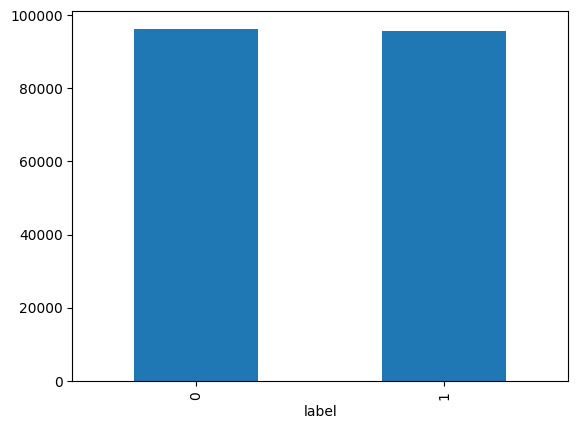

In [13]:
# 막대그래프로 그려보기
review_df.label.value_counts().plot(kind='bar')
# review_df.groupby('label').size().plot(kind='bar')

In [14]:
# 입력 데이터와 정답데이터 추출  (list)
review_list = list(review_df.tokens)
label_list = list(review_df.label)
len(review_list), len(label_list)

(192001, 192001)

In [15]:
# 학습 데이터와 테스트 데이터 분리
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(review_list, label_list, test_size=0.1)
len(train_X), len(test_X), len(train_y), len(test_y)

(172800, 19201, 172800, 19201)

### 1-4. 학습 데이터 준비
    1-4-1. Integer Encoding을 위한 tokenizer 생성
    1-4-2. 입력 데이터 Integer Encoding
    1-4-3. 입력 데이터 Padding
    1-4-4. 정답 데이터 원핫인코딩

#### 1-4-1. Integer Encoding을 위한 tokenizer 생성
* num_words = 사용할 단어 수(vocab_size) + 1 (0은 OOV에 할당)

In [16]:
# 단어 수 제한없이 Tokenizer 생성하여 단어 수 확인
from tensorflow.keras.preprocessing.text import Tokenizer
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(train_X)
len(test_tokenizer.word_index)

108301

In [26]:
# 등장 빈도수를 threshold로 설정하여 버릴 단어가 차지하는 비율 확인
from mylib.my_utils import rare_owrd_status
threshold = 2
rare_owrd_status(threshold, test_tokenizer.word_counts.items())

전체 단어 : 108,301개 2,289,337번
희귀 단어 (등장빈도 2번 미만) : 58,288개 58,288번
희귀 단어 비율 : 단어 수 53.82%, 빈도 수 2.55%
희귀 단어를 뺀 단어 수 : 50,013개 97.45%


In [23]:
# 단어 수를 제한하여 tokenizer 생성
num_vocab = 40000
num_words = num_vocab + 1
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(train_X)
len(tokenizer.word_counts), tokenizer.num_words

(108301, 40001)

#### 1-4-2. 입력 데이터 Integer Encoding
* 제한된 단어에만 index를 부여하므로, 희귀 단어로만 구성된 review는 단어가 0이 되므로 결측치에 해당 -> 결측치 제거

In [27]:
# 입력 데이터 Integer Encoding
encoded_train_X = tokenizer.texts_to_sequences(train_X)
print(len(encoded_train_X))
print(encoded_train_X[:5])

172800
[[131, 4, 2581, 453, 312, 563, 16, 996, 22, 2299, 260, 100, 426, 71], [726, 25, 273, 850], [52, 5124, 645, 6, 51, 8115, 8, 15, 6944, 810], [505, 2155, 245, 22, 692, 14636, 250, 767, 88, 585, 8, 7, 19133, 810, 768, 4, 631], [12, 999, 1, 6421, 1474, 1626, 199, 3, 3034, 6, 466, 47, 478, 560, 1102, 17, 34, 2, 988, 239, 14, 93, 97, 2695, 116, 36, 619, 23, 4, 3152, 239, 738, 2, 9, 569]]


In [28]:
# 길이가 0인 리뷰의 index 추출
null_index = [index for index, review in enumerate(encoded_train_X) if len(review) < 1]
len(null_index)

343

In [29]:
# 길이가 0인 리뷰가 있는 경우, 길이가 1 이상인 리뷰로 학습데이터 재구성
new_train_X = [review for index, review in enumerate(encoded_train_X) if index not in null_index]
new_train_y = [label for index, label in enumerate(train_y) if index not in null_index]
len(new_train_X), len(new_train_y)

(172457, 172457)

In [22]:
# 다른 방식
new_train_X = []
new_train_y = []
for i in range(len(encoded_train_X)):
    if len(encoded_train_X[i]) > 0:
        new_train_X.append(encoded_train_X[i])
        new_train_y.append(train_y[i])

len(new_train_X), len(new_train_y)

(172184, 172184)

#### 1-4-3. 입력 데이터 padding
* 입력 데이터의 길이(max_len)를 정하여 padding

array([[<Axes: title={'center': '0'}>]], dtype=object)

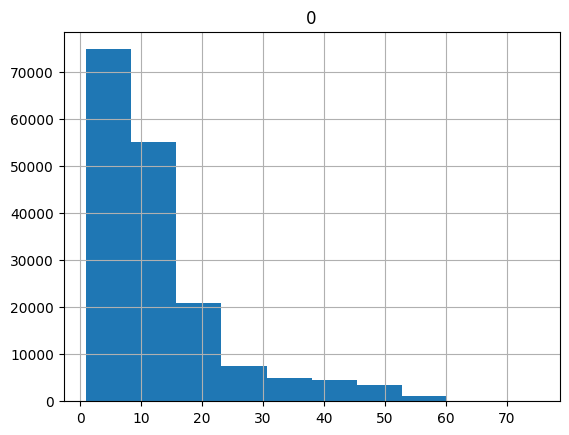

In [30]:
# 리뷰 길이 분포 확인 (히스토그램 그려보기)
len_df = pd.DataFrame([len(review) for review in new_train_X])
len_df.hist()

In [31]:
# 최대, 최소, 평균 등 정보 확인
len_df.describe()

,0
count,172457.000000
mean,12.820721
std,10.687760
min,1.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,75.000000


In [25]:
import importlib
import mylib.my_utils
importlib.reload(mylib.my_utils)

<module 'mylib.my_utils' from 'd:\\Lecture\\TextMining26\\mylib\\my_utils.py'>

In [39]:
from mylib.my_utils import below_threshold_len_from_list as btlfl
# 길이가 max_len 이하인 데이터의 비중 확인
max_len = 60
btlfl(max_len, new_train_X)

길이가 60 이하인 텍스트의 비율 : 99.9640%


In [40]:
# max_len 길이로 입력 데이터 padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_X = pad_sequences(new_train_X, maxlen=max_len)
len(train_X), train_X[:2]

(172457,
 array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,  131,    4, 2581,  453,  312,  563,   16,  996,   22,
         2299,  260,  100,  426,   71],
        [   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,  726,   25,  273,  850]]))

#### 1-4-4. 정답 데이터 one-hot encoding

In [41]:
from tensorflow.keras.utils import to_categorical
train_y = to_categorical(new_train_y)
len(train_y), train_y[:2]

(172457,
 array([[1., 0.],
        [0., 1.]], dtype=float32))

### 1-5. 테스트 데이터 준비
    1-5-1. 입력 데이터 Integer Encoding (결측치제거) 
    1-5-2. 입력 데이터 padding
    1-5-3. 정답 데이터 one-hot encoding

In [42]:
# 입력 데이터 Integer Encoding
encoded_test_X = tokenizer.texts_to_sequences(test_X)
print(len(encoded_test_X), encoded_test_X[:2])

19201 [[422, 6, 97, 63, 10, 1074, 69, 235, 7797, 914], [75, 5, 734, 12, 25, 1, 2156, 33821, 142, 961]]


In [43]:
# 길이가 0인 리뷰의 index 추출 -> 있으면 길이가 1 이상인 리뷰만으로 테스트 데이터 재구성 
null_index = [index for index, review in enumerate(encoded_test_X) if len(review) < 1]
len(null_index)

39

In [45]:
new_test_X = [review for index, review in enumerate(encoded_test_X) if index not in null_index]
new_test_y = [label for index, label in enumerate(test_y) if index not in null_index]
len(new_test_X), len(new_test_y)

(19162, 19162)

In [46]:
# 입력 데이터 padding
test_X = pad_sequences(new_test_X, maxlen=max_len)
len(test_X), test_X[:2]

(19162,
 array([[    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,   422,     6,    97,    63,
            10,  1074,    69,   235,  7797,   914],
        [    0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,    75,     5,   734,    12,
            25,     1,  2156, 33821,   142,   961]]))

In [47]:
# 정답 데이터 one-hot encoding
test_y = to_categorical(new_test_y)
len(test_y), test_y[:2]

(19162,
 array([[1., 0.],
        [1., 0.]], dtype=float32))

## 2. 모델 구축 및 컴파일

In [201]:
# 모델 설계
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, LeakyReLU
from tensorflow.keras.regularizers import l2
# num_features: 입력개수, embedding_dim: 차원, input_length: 입력의 길이(데이터의 길이)
# Embedding layer의 하이퍼 파라미터
num_features = num_words
embedding_dim = 128
input_length = max_len
# LSTM
rnn_nodes = 128
# 은닉층 dense
dense_nodes = 64
# 출력층 dense
output_nodes = 2

rnn_model = [
    Embedding(num_features, embedding_dim, input_length=input_length),
    LSTM(rnn_nodes),
    Dense(dense_nodes, activation='tanh'), #Dense(dense_nodes, activation='tanh'),Dense(dense_nodes, activation='relu')
    Dense(output_nodes, activation='softmax')
]

In [202]:
# 모델 생성
from tensorflow.keras.models import Sequential
model = Sequential(rnn_model)
model.summary()

Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_28 (Embedding)    (None, 60, 128)           5120128   
                                                                 
 lstm_28 (LSTM)              (None, 128)               131584    
                                                                 
 dense_56 (Dense)            (None, 64)                8256      
                                                                 
 dense_57 (Dense)            (None, 2)                 130       
                                                                 
Total params: 5,260,098
Trainable params: 5,260,098
Non-trainable params: 0
_________________________________________________________________


In [203]:
# 모델 컴파일
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Adam
# 학습 설계 : 생성한 모델에 학습 관련 하이퍼파라미터를 설정
model.compile(
    optimizer=RMSprop(learning_rate=0.005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)
# model.compile(
#     optimizer='adam', 
#     loss='binary_crossentropy', 
#     metrics=['accuracy']
# )


In [204]:
# EarlyStopping, ModelCheckpoint callback 함수 설정
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# es = EarlyStopping(
#     monitor='val_loss',       # 검증 손실을 기준으로 조기 종료 판단
#     patience=5,               # 성능 개선이 없어도 5에포크까지는 대기
#     restore_best_weights=True # 가장 성능이 좋았던 시점의 가중치로 복원
# )
# mc = ModelCheckpoint(
#     filepath='./model/best_model.keras', # 모델이 저장될 파일 경로
#     monitor='val_loss',          # 검증 손실이 가장 낮을 때 저장
#     save_best_only=True          # 최고 성능의 모델만 덮어쓰기
# )
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=1
)
checkpoint_filepath = './model/best_model.h5'
mc = ModelCheckpoint(
    checkpoint_filepath,
    monitor= 'val_loss',
    mode= 'min',
    save_best_only=True
)

## 3. 모델 학습

In [205]:
# 모델 학습
model.fit(
    train_X, train_y,           # 훈련 데이터와 정답 레이블
    epochs=20,                  # 최대 학습 횟수
    batch_size=128,             # 한 번에 학습할 데이터 묶음 크기
    validation_split=0.1,        # 검증용 데이터
    callbacks=[es, mc]          # 위에서 설정한 콜백 리스트 적용
)

Epoch 1/20
1213/1213 [==============================] - 12s 9ms/step - loss: 0.3744 - accuracy: 0.8326 - val_loss: 0.3447 - val_accuracy: 0.8477
Epoch 2/20
1213/1213 [==============================] - 10s 9ms/step - loss: 0.2781 - accuracy: 0.8850 - val_loss: 0.3233 - val_accuracy: 0.8640
Epoch 3/20
1213/1213 [==============================] - 11s 9ms/step - loss: 0.2329 - accuracy: 0.9084 - val_loss: 0.3377 - val_accuracy: 0.8519
Epoch 4/20
1213/1213 [==============================] - 11s 9ms/step - loss: 0.1955 - accuracy: 0.9256 - val_loss: 0.3482 - val_accuracy: 0.8608
Epoch 5/20
1213/1213 [==============================] - 10s 8ms/step - loss: 0.1631 - accuracy: 0.9399 - val_loss: 0.3739 - val_accuracy: 0.8516
Epoch 5: early stopping


## 4. 모델 평가

In [208]:
# 저장된 모델 로딩하여, 테스트 데이터로 평가
from tensorflow.keras.models import load_model

# 1. 저장된 최고 성능의 모델 불러오기
# (앞서 ModelCheckpoint에서 지정한 파일명을 적어주세요)
loaded_model = load_model(checkpoint_filepath)
# model.load_weights(checkpoint_filepath)

# 2. 테스트 데이터로 모델 평가하기
# (본인의 테스트 데이터 변수명인 X_test, y_test 등으로 변경하세요)
# test_loss, test_acc = loaded_model.evaluate(test_X, test_y, verbose=2)
test_loss, test_acc = loaded_model.evaluate(test_X, test_y)

print(f"\n✨ 테스트 손실(Loss): {test_loss*100:.4f}")
print(f"✨ 테스트 정확도(Accuracy): {test_acc*100:.4f}")

599/599 [==============================] - 3s 4ms/step - loss: 0.3177 - accuracy: 0.8662

✨ 테스트 손실(Loss): 31.7664
✨ 테스트 정확도(Accuracy): 86.6246


In [46]:
# predict로 테스트 데이터의 예측값 구기기
import numpy as np
results = model.predict(test_X)
print(results[:1])
labels = ['부정', '긍정']
user_outputs = [labels[np.argmax(result)] for result in results]
print(user_outputs[:10])

599/599 [==============================] - 2s 2ms/step
[[0.99614054 0.00385947]]
['부정', '긍정', '긍정', '부정', '긍정', '긍정', '부정', '긍정', '긍정', '긍정']


In [47]:
# sklearn의 classification_report()로 평가 결과 확인
from sklearn.metrics import classification_report
pred_labels = [0, 1]
preds = [pred_labels[np.argmax(result)] for result in results]
print(classification_report(new_test_y, preds))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      9499
           1       0.86      0.85      0.86      9663

    accuracy                           0.86     19162
   macro avg       0.86      0.86      0.86     19162
weighted avg       0.86      0.86      0.86     19162



## 5. 예측

In [48]:
# 입력된 리뷰에 대한 긍부정 판단 함수
def analyze_sentiment(review):
    # 데이터 준비 : 정제, #한국어 형태소 분석, # Integer Encoding, # padding
    tokens = [word for word in t.morphs(review)]
    encoded_tokens = tokenizer.texts_to_sequences([tokens])
    X = pad_sequences(encoded_tokens)
    # 예측
    results = model.predict(X, verbose=0)
    labels = ['부정', '긍정']
    index = np.argmax(results[0])
    user_output = labels[index]
    return user_output,results[0][index]

In [49]:
# 함수 테스트
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_output, prob = analyze_sentiment(review)
    print(f'{review} --> {user_output}({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(99.56%)
하품만 나온다 --> 부정(99.93%)
이 영화 핵노잼 ㅠㅠ --> 부정(99.98%)
이딴게 영화냐 ㅉㅉ --> 부정(99.99%)
와 개쩐다 --> 긍정(99.39%)
감독 뭐하는 놈이냐 --> 부정(99.93%)
정말 세계관 최강자들의 영화다 --> 긍정(62.72%)


## 6. 배포 (모델 저장 및 재사용)
    6-1. 모델 저장
    6-2. SentimentAnalyzer 클래스 구현
        *  저장된 모델 로딩 및 사용

### 6-1. 모델 저장 

In [50]:
# t (Okt 객체) -> Okt 클래스 활용하여 생성

# keras 학습 모델저장 
model.save('./model/sa_movie_model.keras')

In [51]:
# Integer Encoding을 위한 파이썬 객체 직렬화 (encoder) : tokenizer
import joblib
joblib.dump(tokenizer, './model/sa_movie_encoder.pkl')

['./model/sa_movie_encoder.pkl']

### 6-2. SentimentAnalyzer 클래스 구현
- 객체 생성 시 예측 모델, Integer Encoder 로딩
- 한국어 형태소 분석기 정의
- 입력된 리뷰의 긍부정 판단 함수

In [52]:
from tensorflow.keras.models import load_model
from konlpy.tag import Okt

class SentimentAnalyzer:
    def __init__(self, model_file, encoder_file):
        self.model = load_model(model_file)
        self.encoder = joblib.load(encoder_file)
        self.korean_tokenizer = Okt().morphs

    def analyze_sentiment(self, review):
        # 데이터 준비 : 정제, #한국어 형태소 분석, # Integer Encoding, # padding
        tokens = [word for word in self.korean_tokenizer(review)]
        encoded_tokens = self.encoder.texts_to_sequences([tokens])
        X = pad_sequences(encoded_tokens, maxlen=self.model.input_shape[1])
        # 예측
        results = self.model.predict(X, verbose=0)
        labels = ['부정', '긍정']
        index = np.argmax(results[0])
        user_output = labels[index]
        return user_output,results[0][index]

In [53]:
sa = SentimentAnalyzer('./model/sa_movie_model.keras', './model/sa_movie_encoder.pkl')
reviews = [
    '이 영화 개꿀잼 ㅋㅋㅋ',
    '하품만 나온다',
    '이 영화 핵노잼 ㅠㅠ',
    '이딴게 영화냐 ㅉㅉ',
    '와 개쩐다',
    '감독 뭐하는 놈이냐',
    '정말 세계관 최강자들의 영화다'
]

for review in reviews:
    user_output, prob = sa.analyze_sentiment(review)
    print(f'{review} --> {user_output}({prob*100:.2f}%)')

이 영화 개꿀잼 ㅋㅋㅋ --> 긍정(99.39%)
하품만 나온다 --> 부정(99.99%)
이 영화 핵노잼 ㅠㅠ --> 부정(99.99%)
이딴게 영화냐 ㅉㅉ --> 부정(100.00%)
와 개쩐다 --> 긍정(99.35%)
감독 뭐하는 놈이냐 --> 부정(99.98%)
정말 세계관 최강자들의 영화다 --> 긍정(51.13%)
